# A 2D gradient echo, three times over

One spoiled 2D GRE, built three ways, each answering a question the other two cannot.

| | | Answers |
|---|---|---|
| **1** | raw pypulseq events in a `LogicBlock` | *does the compile path stand alone?* — and it is the baseline the other two must reproduce |
| **2** | the four leaf modules, composed inline | *what is a TR actually made of?* — every intermediate printed, the couplings made explicit |
| **3** | the same composition written as a module | *how does working code become something reusable?* |

**This notebook does not import `GRE2D` or `GRE2DTR`.** It writes them. The class in pass 3 is the
one in `seqcraft/modules/kernel/gre_2d_tr.py`, and a test in `tests/` asserts the two compile
identically, so the notebook cannot drift from the package without CI noticing.

Everything here is arithmetic — areas, moments, timing, `sc.kspace()`. Nothing needs a simulator.
[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) takes the `.seq` files
this writes and asks whether they produce the image we expect.

**Output:** three `.seq` files in `seq/`, the nominal k-space beside them, and the three sampling
patterns.

## 0. The scanner, and the protocol

`opts` is a plain `pypulseq.Opts` — there is no seqcraft scanner class. The three dead times are
stated rather than defaulted: pypulseq defaults all three to zero, which is wrong on every real
scanner, and a sequence built on those compiles and validates cleanly before the console refuses
it.

**The flip angle is the one protocol number worth arguing about here.** For a spoiled GRE the
signal peaks at the Ernst angle, $lpha_E = rccos(e^{-TR/T_1})$, which at TR = 15 ms and
$T_1 pprox 900$ ms is about 10°. Going *above* it trades signal for T1 contrast; going below
trades T1 contrast for a more proton-density-weighted image. 5° is the second choice, and it is
what makes the grey/white contrast in `02` read the way it does.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (220.0, 220.0)      # (x, y)  -- readout, phase
MATRIX = (128, 128)          # (nx, ny) -- readout, phase
THICKNESS_MM = 5.0
FLIP_DEG = 5.0
BANDWIDTH_HZ_PX = 400.0
TR_S = 10e-3
DUMMIES = 5
RF_SPOIL_DEG = 117.0
SPOIL_CYCLES = 4.0

NX, NY = MATRIX
CENTER_LINE = NY // 2        # one convention, three consumers: k, the LIN label, the .seq

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

ernst_deg = np.rad2deg(np.arccos(np.exp(-TR_S / 0.9)))      # white matter, T1 ~ 900 ms at 3 T

print(f'{NX} x {NY} over {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'in-plane voxel: {FOV_MM[0] / NX:.2f} x {FOV_MM[1] / NY:.2f} mm')
print(f'flip {FLIP_DEG:.0f} deg, below the {ernst_deg:.1f} deg Ernst angle at this TR: '
      f'proton-density weighted rather than T1 weighted')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128 over 220 x 220 mm, 5 mm slice
in-plane voxel: 1.72 x 1.72 mm
flip 5 deg, below the 8.5 deg Ernst angle at this TR: proton-density weighted rather than T1 weighted


---
# Pass 1 — raw pypulseq events

No modules at all. Every event comes from a `pp.make_*` call and goes into one `LogicBlock` with a
start time. This is the proof that the compile path stands alone, and it is the baseline passes 2
and 3 have to reproduce event for event.

### The excitation

`make_sinc_pulse(..., return_gz=True)` hands back the pulse, its selection gradient **and** a
rephaser. The rephaser is the part worth checking rather than trusting: it must undo the area
after the pulse's *effective centre*, not half the gradient's total area. The two agree only for a
symmetric pulse.

In [2]:
rf, gz, gzr = pp.make_sinc_pulse(
    flip_angle=np.deg2rad(FLIP_DEG),
    duration=3e-3,
    slice_thickness=THICKNESS_MM / 1e3,
    delay=opts.rf_dead_time,
    use='excitation',
    return_gz=True,
    system=opts,
)


def area_until(event, t_end):
    """Exact area of a gradient event from its node to `t_end`, in 1/m."""
    times, amps = sc.events.knots_of(event)
    if t_end >= times[-1]:
        return float(sc.events.pwl_moment(times, amps))
    cut = int(np.searchsorted(times, t_end))
    edge = float(np.interp(t_end, times, amps))
    return float(sc.events.pwl_moment(np.append(times[:cut], t_end), np.append(amps[:cut], edge)))


time_to_center = float(rf.delay) + float(pp.calc_rf_center(rf)[0])
after_center = float(gz.area) - area_until(gz, time_to_center)

print(f'effective centre      {time_to_center * 1e6:8.1f} us into the block')
print(f'gz area after centre  {after_center:8.2f} 1/m')
print(f'gzr area              {float(gzr.area):8.2f} 1/m')
print(f'sum                   {after_center + float(gzr.area):8.2e}   <- the invariant')
print()
print(f'half the total area   {-float(gz.area) / 2:8.2f} 1/m   '
      f'(the same here only because a sinc is symmetric)')

effective centre        1600.0 us into the block
gz area after centre    406.67 1/m
gzr area               -406.67 1/m
sum                   -5.68e-14   <- the invariant

half the total area    -406.67 1/m   (the same here only because a sinc is symmetric)


### The readout

The line that matters is the prephaser. The readout gradient accumulates moment from the instant
it starts *ramping*, so k at the echo is the prephaser plus the ramp-up plus whatever flat top
precedes the echo:

$$A_\mathrm{pre} = -\left(\tfrac12 G\,t_\mathrm{rise} + G\,t_\mathrm{flat\ before\ echo}\right)$$

`gx.flat_area / 2` drops the ramp entirely. `gx.area / 2` includes it and is still half a $\Delta k$
short, because k = 0 belongs at sample index `nx // 2`, whose centre time is **half a dwell** after
the midpoint of the ADC window — that is the convention a centred inverse FFT assumes.

Integrating the gradient's own knots up to the echo gives both terms for free, and generalises to
ramp sampling and partial echo without a second derivation.

In [3]:
dk_x = 1e3 / FOV_MM[0]                       # k-space step along the readout, 1/m
dk_y = 1e3 / FOV_MM[1]

dwell = round(1 / (BANDWIDTH_HZ_PX * NX) / opts.adc_raster_time) * opts.adc_raster_time
flat_time = float(sc.Raster(opts.grad_raster_time).ceil(NX * dwell))

gx = pp.make_trapezoid('x', amplitude=dk_x / dwell, flat_time=flat_time, system=opts)
# The sampling offset goes in the ADC's own delay and the node goes where the gradient starts:
# make_adc raises a delay below adc_dead_time up to it, and seqcraft preserves an event's delay
# rather than folding it away, so an offset written into the node would be counted twice.
adc = pp.make_adc(num_samples=NX, dwell=dwell, delay=gx.rise_time, system=opts)

n_pre = NX // 2                                        # samples before the echo
t_echo_in_gx = float(adc.delay) + (n_pre + 0.5) * dwell
prephaser_area = -area_until(gx, t_echo_in_gx)

print(f'dwell                {dwell * 1e9:9.0f} ns    ({1 / (dwell * NX):.1f} Hz/px achieved)')
print(f'readout amplitude    {float(gx.amplitude):9.0f} Hz/m  '
      f'({float(gx.amplitude) / opts.max_grad * 100:.0f} % of the limit)')
print(f'echo, in gx          {t_echo_in_gx * 1e6:9.1f} us')
print()
print(f'prephaser, integrated  {prephaser_area:9.3f} 1/m   <- what this notebook uses')
print(f'         -gx.area / 2  {-float(gx.area) / 2:9.3f} 1/m   '
      f'(off by {abs(prephaser_area + float(gx.area) / 2) / dk_x:.2f} dk: the half dwell)')
print(f'    -gx.flat_area / 2  {-float(gx.flat_area) / 2:9.3f} 1/m   '
      f'(off by {abs(prephaser_area + float(gx.flat_area) / 2) / dk_x:.2f} dk: the ramp)')

dwell                    19500 ns    (400.6 Hz/px achieved)
readout amplitude       233100 Hz/m  (14 % of the limit)
echo, in gx             1297.8 us

prephaser, integrated   -297.844 1/m   <- what this notebook uses
         -gx.area / 2   -296.037 1/m   (off by 0.40 dk: the half dwell)
    -gx.flat_area / 2   -291.375 1/m   (off by 1.42 dk: the ramp)


### The winder coupling, and its three participants

Three gradients play **at the same time**, on three different axes, so overlap costs nothing in
the tree and nothing on the hardware:

| axis | | |
|---|---|---|
| `z` | the **slice rephaser** | undoes the selection gradient after the pulse's centre |
| `y` | the **phase-encode blip** | the line being acquired |
| `x` | the **readout prephaser** | winds k to the start of the readout |

The rephaser is the one that is easy to get wrong, because `make_sinc_pulse` hands it back
attached to the pulse and it reads as part of the excitation. Waiting for it before starting the
other two adds its **whole duration** to TE and buys nothing at all.

Whichever is longest sets the period; the other two are stretched to match rather than padded with
a delay, because a delay would push the echo later for nothing. So each is designed at its own
minimum first, the maximum is taken, and then all three are rebuilt at that duration.

In [4]:
grad_raster = sc.Raster(opts.grad_raster_time)

# Designed at the largest area, then scaled per line: that is what keeps every line the same
# length, so the placement arithmetic below never depends on which line is being acquired.
gy_min = pp.make_trapezoid('y', area=CENTER_LINE * dk_y, system=opts)
gx_pre_min = pp.make_trapezoid('x', area=prephaser_area, system=opts)

winder_s = float(grad_raster.ceil(max(
    float(pp.calc_duration(gzr)),                       # the slice rephaser, on z
    float(pp.calc_duration(gy_min)),                    # the phase-encode blip, on y
    float(pp.calc_duration(gx_pre_min)),                # the readout prephaser, on x
)))

gy_max = pp.make_trapezoid('y', area=CENTER_LINE * dk_y, duration=winder_s, system=opts)
gx_pre = pp.make_trapezoid('x', area=prephaser_area, duration=winder_s, system=opts)
gz_spoil = pp.make_trapezoid('z', area=SPOIL_CYCLES / (THICKNESS_MM / 1e3), system=opts)

print(f'slice rephaser,    shortest  {float(pp.calc_duration(gzr)) * 1e6:7.1f} us   z')
print(f'phase-encode blip, shortest  {float(pp.calc_duration(gy_min)) * 1e6:7.1f} us   y')
print(f'readout prephaser, shortest  {float(pp.calc_duration(gx_pre_min)) * 1e6:7.1f} us   x')
print(f'winder (the maximum)         {winder_s * 1e6:7.1f} us')
print()
print(f'spoiler                      {float(pp.calc_duration(gz_spoil)) * 1e6:7.1f} us  '
      f'({SPOIL_CYCLES:.0f} turns across {THICKNESS_MM:.0f} mm)')

slice rephaser,    shortest    520.0 us   z
phase-encode blip, shortest    440.0 us   y
readout prephaser, shortest    440.0 us   x
winder (the maximum)           520.0 us

spoiler                        740.0 us  (4 turns across 5 mm)


### Placement, TE and TR

Every offset below is measured from something that was built, not declared. `LogicBlock.duration`
is measured from the nodes, so nothing here can claim a length it does not play — and the two
*semantic* offsets the tree cannot know, `time_to_center` and the echo, come from the physics
above.

In [5]:
block_raster = sc.Raster(opts.block_duration_raster)

# The winder begins where the slice rephaser does -- not after it.  The transmit chain has to be
# clear of the pulse first (calc_duration includes the ringdown) and the selection gradient has
# to have finished; after that all three axes work together.
t_rephaser = float(pp.calc_duration(gz))
t_winder = float(grad_raster.ceil(max(t_rephaser, float(pp.calc_duration(rf)))))
t_gx = t_winder + winder_s
t_tail = t_gx + float(pp.calc_duration(gx))
tail_s = max(float(pp.calc_duration(gy_max)), float(pp.calc_duration(gz_spoil)))

min_te_s = t_winder - time_to_center + winder_s + t_echo_in_gx
min_tr_s = float(block_raster.ceil(t_tail + tail_s))


def tr_fill(t_end):
    """The delay that runs from `t_end` to the end of the repetition, on the block raster.

    Snapped rather than subtracted straight: every term is already a multiple of the raster, so
    the rounding only removes the last bit of float error -- which is otherwise enough to make
    two identically specified sequences end with different delays, and therefore to make them
    compare unequal for no physical reason.
    """
    return pp.make_delay(block_raster.ceil(TR_S - t_end))

assert TR_S >= min_tr_s, f'TR of {TR_S * 1e3:.2f} ms is below the minimum {min_tr_s * 1e3:.2f} ms'
assert winder_s >= float(pp.calc_duration(gzr)) - 1e-9, 'the readout would start mid-rephaser'

print(f'pulse ends        {float(pp.calc_duration(rf)) * 1e3:7.3f} ms')
print(f'rephaser starts   {t_rephaser * 1e3:7.3f} ms   <- and so does the winder')
print(f'readout starts    {t_gx * 1e3:7.3f} ms')
print(f'rewind + spoil    {t_tail * 1e3:7.3f} ms')
print()
print(f'TE  {min_te_s * 1e3:7.3f} ms   (the minimum: nothing is padding it)')
print(f'    {(min_te_s + float(pp.calc_duration(gzr))) * 1e3:7.3f} ms   '
      f'is what waiting for the rephaser would have cost')
print(f'TR  {TR_S * 1e3:7.3f} ms   (minimum {min_tr_s * 1e3:.3f} ms, so {(TR_S - min_tr_s) * 1e3:.3f} ms of fill)')

pulse ends          3.130 ms
rephaser starts     3.150 ms   <- and so does the winder
readout starts      3.670 ms
rewind + spoil      6.250 ms

TE    3.368 ms   (the minimum: nothing is padding it)
      3.888 ms   is what waiting for the rephaser would have cost
TR   10.000 ms   (minimum 6.990 ms, so 3.010 ms of fill)


### One repetition

Two things vary between repetitions and nothing else does: **which line** and **what carrier
phase**. `acquire=False` drops the ADC and the label and changes nothing else, which is what makes
a dummy establish the steady state that then gets acquired.

Note the ADC's phase offset. **The receiver is phase-locked to the transmitter** — whatever phase
the RF is given, the ADC has to demodulate at. Leaving the receiver at zero while the pulse runs
a spoiling schedule writes that schedule's quadratic phase straight into $k_y$; measured on a
single off-centre voxel it scattered a point source across the entire phase-encode direction while
the readout direction stayed perfectly correct.

In [6]:
def repetition_raw(line, phase_deg=0.0, acquire=True):
    """One TR, out of raw pypulseq events."""
    phase_rad = float(np.deg2rad(phase_deg))
    scale = (line - CENTER_LINE) * dk_y / float(gy_max.area)
    blip = sc.events.derive(pp.scale_grad(gy_max, scale))
    rewind = sc.events.derive(pp.scale_grad(gy_max, -scale))

    out = sc.LogicBlock('GRE2DTR')
    out.add(0.0, sc.events.derive(rf, phase_offset=phase_rad), gz)
    out.add(t_rephaser, gzr)                      # z -- and the next line is y and x, at once
    out.add(t_winder, blip, gx_pre)
    if acquire:
        # The label goes with the readout rather than with the ADC.  The compiler assigns each
        # label to the first ADC at or after its own time, so anywhere in this gap is equivalent
        # -- what matters is that it is not left after the readout it addresses.
        out.add(t_winder, pp.make_label(type='SET', label='LIN', value=int(line)))
    out.add(t_gx, gx)
    if acquire:
        out.add(t_gx, sc.events.derive(adc, phase_offset=phase_rad))
    out.add(t_tail, rewind, gz_spoil)
    out.add(t_tail + tail_s, tr_fill(t_tail + tail_s))
    return out


one = repetition_raw(line=CENTER_LINE + 8)
print(one.describe())

GRE2DTR  10.00 ms
  +0.0 us  rf
  +0.0 us  trap z
  +3150.0 us  trap z
  +3150.0 us  trap y
  +3150.0 us  trap x
  +3150.0 us  labelset
  +3670.0 us  trap x
  +3670.0 us  adc
  +6250.0 us  trap y
  +6250.0 us  trap z
  +6990.0 us  delay


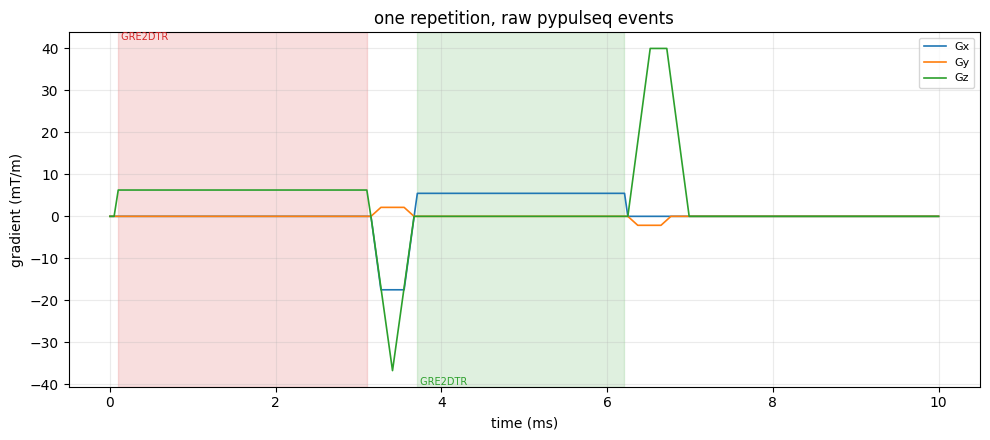

In [7]:
fig = sc.plot_block(one, opts, title='one repetition, raw pypulseq events')

### The loop, and the RF-spoiling schedule

The dummy repetitions come first, and **the phase counter runs across them**. Repetition *n* gets
`0.5 * 117 * n * (n + 1)` with *n* counted from the first dummy, not from the first acquired line.
Restarting it at the acquisition is a real and quiet bug: the steady state the dummies established
is a steady state *of a particular phase sequence*, and resetting the counter discards it at the
moment it starts to matter.

In [8]:
def scan(repetition, lines, dummies=DUMMIES, spoil_deg=RF_SPOIL_DEG):
    """Stack one repetition per line, after `dummies` unsampled ones."""
    def phase_deg(n):
        return 0.5 * spoil_deg * n * (n + 1)

    out = sc.LogicBlock('scan')
    for n in range(dummies):
        out.add(n * TR_S, repetition(lines[0], phase_deg=phase_deg(n), acquire=False))
    for index, line in enumerate(lines):
        n = dummies + index
        out.add(n * TR_S, repetition(line, phase_deg=phase_deg(n)))
    return out


full_lines = tuple(range(NY))
raw_scan = scan(repetition_raw, full_lines)
raw_seq = sc.compile(raw_scan, opts, name='gre_2d_full')

print(f'{len(raw_scan)} repetitions, {len(raw_seq.block_events)} pulseq blocks, '
      f'{raw_seq.duration()[0]:.3f} s')

133 repetitions, 665 pulseq blocks, 1.330 s


C:\Users\bughh\AppData\Local\Temp\ipykernel_77284\803889423.py:17: SeqCraftWarning: 502 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR (grad 110% at 3.150 ms), scan.GRE2DTR (slew 165% at 3.150 ms), scan.GRE2DTR (grad 109% at 6.250 ms), scan.GRE2DTR (slew 137% at 6.250 ms), scan.GRE2DTR (grad 110% at 13.150 ms) (+497 more sites)
  raw_seq = sc.compile(raw_scan, opts, name='gre_2d_full')


> The compile warns that some blocks exceed the **vector-norm** gradient limit. That is expected
> and is not a violation: a phase-encode blip on `y` beside a prephaser on `x` reaches √2 times the
> per-axis slew in vector magnitude while every amplifier axis stays within its own limit. seqcraft
> reports the per-axis limits as errors and the vector norm as a warning for exactly this reason.

### The arithmetic checks

Four, and each catches a different way the sequence can be wrong while still compiling.

In [9]:
k = sc.kspace(raw_scan, opts)
k_adc = k['k_adc'].reshape(3, len(full_lines), NX)

# 1. every readout sat on the line it was asked for
encoded = np.round(k_adc[1, :, 0] / dk_y).astype(int) + CENTER_LINE
assert list(encoded) == list(full_lines), 'the acquired lines are not the requested ones'

# 2. k = 0 on every axis at the echo sample of the centre line
at_echo = k_adc[:, full_lines.index(CENTER_LINE), n_pre]
assert np.allclose(at_echo, 0.0, atol=1e-3), f'k at the echo is {at_echo}'

# 3. the rewinder rewinds: no phase encoding survives one repetition
assert abs(sc.moments(repetition_raw(line=3))['y']) < 1e-9

# 4. the measured echo time is the one the arithmetic predicted.  The dummies come first and
#    have no ADC, so the excitation this echo belongs to is number DUMMIES, not number zero --
#    an off-by-DUMMIES here would report TE as one whole TR too long.
measured_te = k['t_adc'][n_pre] - float(k['t_excitation'][DUMMIES])
assert abs(measured_te - min_te_s) < 1e-9

print(f'lines acquired      {encoded[0]} ... {encoded[-1]}')
print(f'k at the echo       {np.abs(at_echo).max():.2e} 1/m')
print(f'per-TR ky moment    {sc.moments(repetition_raw(line=3))["y"]:.2e} 1/m')
print(f'TE, measured        {measured_te * 1e3:.3f} ms  (predicted {min_te_s * 1e3:.3f} ms)')

lines acquired      0 ... 127
k at the echo       1.46e-10 1/m
per-TR ky moment    3.41e-13 1/m
TE, measured        3.368 ms  (predicted 3.368 ms)


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 502 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR (grad 110% at 3.150 ms), scan.GRE2DTR (slew 165% at 3.150 ms), scan.GRE2DTR (grad 109% at 6.250 ms), scan.GRE2DTR (slew 137% at 6.250 ms), scan.GRE2DTR (grad 110% at 13.150 ms) (+497 more sites)
  seq = compile_sequence(tree, opts)


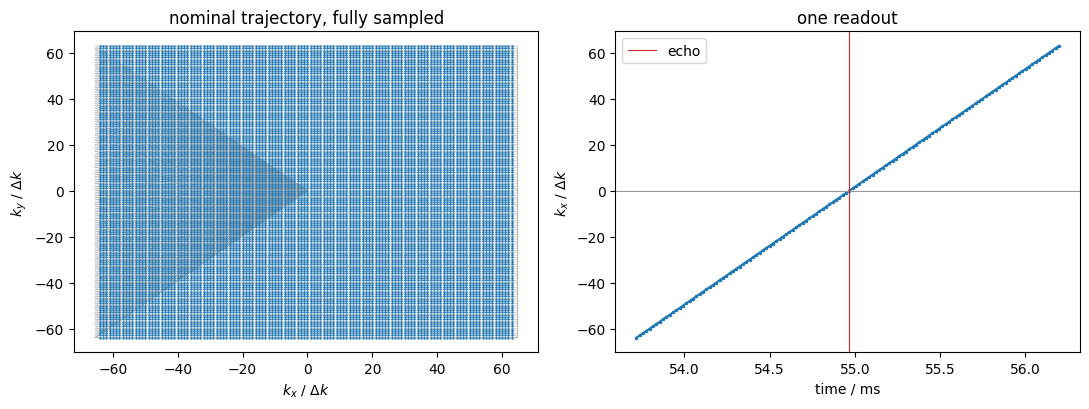

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(k['k'][0] / dk_x, k['k'][1] / dk_y, lw=0.4, color='0.7')
axes[0].plot(k_adc[0] / dk_x, k_adc[1] / dk_y, '.', ms=1.5, color='C0')
axes[0].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$',
            title='nominal trajectory, fully sampled')
axes[1].plot(k['t_adc'][:NX] * 1e3, k_adc[0, 0] / dk_x, '.-', ms=3)
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].axvline(k['t_adc'][n_pre] * 1e3, color='C3', lw=0.8, label='echo')
axes[1].set(xlabel='time / ms', ylabel='$k_x$ / $\\Delta k$', title='one readout')
axes[1].legend()
fig.tight_layout()

---
# Pass 2 — the four leaf modules, composed inline

The same repetition, out of `Excitation`, `PhaseEncode`, `CartesianLine` and `spoiler`. Still no
kernel and no sequence class: the composition is written out in plain cells, because this is where
its real difficulties live and each one is worth seeing alone.

What the modules take over is the arithmetic, not the decisions. The prephaser integral, the
half-dwell offset, the equal-duration invariant across lines, the rephaser: all of that is now
inside. Where each block goes, and what TE and TR are, is still written here.

In [11]:
exc = sc.modules.Excitation(opts=opts, flip_deg=FLIP_DEG, thickness_mm=THICKNESS_MM)

# Indexing the pair at the call site is deliberate.  This is the line that shows which axis is
# which, and it is the one place a transposed image is introduced.
pe_probe = sc.modules.PhaseEncode(opts=opts, fov_mm=FOV_MM[1], matrix=MATRIX[1], axis='y')
ro_probe = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM[0], matrix=MATRIX[0], axis='x',
                                    bandwidth_hz_px=BANDWIDTH_HZ_PX)

# The winder coupling, made visible: each of the three reports its own minimum and accepts an
# override, and none of them knows the other two exist.  The excitation is asked how long its
# rephaser is rather than how long its block is, because the rephaser is a participant here
# rather than a phase to wait through.
winder_module_s = float(grad_raster.ceil(max(
    exc.rephaser_duration_s, pe_probe.min_duration_s, ro_probe.prephaser_duration_s)))

pe = sc.modules.PhaseEncode(opts=opts, fov_mm=FOV_MM[1], matrix=MATRIX[1], axis='y',
                            duration_s=winder_module_s)
ro = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM[0], matrix=MATRIX[0], axis='x',
                              bandwidth_hz_px=BANDWIDTH_HZ_PX,
                              prephaser_duration_s=winder_module_s)
spoil = sc.modules.spoiler(opts, cycles_per_voxel=SPOIL_CYCLES, voxel_mm=THICKNESS_MM, axis='z')

print(f'rephaser module {exc.rephaser_duration_s * 1e6:7.1f} us   raw '
      f'{float(pp.calc_duration(gzr)) * 1e6:7.1f} us')
print(f'winder   module {winder_module_s * 1e6:7.1f} us   raw {winder_s * 1e6:7.1f} us')
print(f'echo     module {ro.time_to_echo() * 1e6:7.1f} us   raw {(winder_s + t_echo_in_gx) * 1e6:7.1f} us')
print(f'centre   module {exc.time_to_center() * 1e6:7.1f} us   raw {time_to_center * 1e6:7.1f} us')
print(f'prephas. module {ro.prephaser_area_per_m:7.3f}      raw {prephaser_area:7.3f}')

rephaser module   520.0 us   raw   520.0 us
winder   module   520.0 us   raw   520.0 us
echo     module  1817.8 us   raw  1817.8 us
centre   module  1600.0 us   raw  1600.0 us
prephas. module -297.844      raw -297.844


In [12]:
t_winder_m = float(grad_raster.ceil(max(
    exc.time_to_rephaser(), float(pp.calc_duration(exc.rf)))))
t_tail_m = t_winder_m + ro().duration
tail_m_s = max(pe(line=0, rewind=True).duration, spoil.duration)

te_module_s = t_winder_m - exc.time_to_center() + ro.time_to_echo()
tr_min_module_s = float(block_raster.ceil(t_tail_m + tail_m_s))

print(f'TE  {te_module_s * 1e3:7.3f} ms   (raw pass: {min_te_s * 1e3:.3f} ms)')
print(f'TR  {tr_min_module_s * 1e3:7.3f} ms minimum   (raw pass: {min_tr_s * 1e3:.3f} ms)')

TE    3.368 ms   (raw pass: 3.368 ms)
TR    6.990 ms minimum   (raw pass: 6.990 ms)


In [13]:
def repetition_inline(line, phase_deg=0.0, acquire=True):
    """One TR, out of the four leaf modules."""
    out = sc.LogicBlock('GRE2DTR')
    out.add(0.0, exc(phase_deg=phase_deg))
    out.add(t_winder_m, pe(line=line))
    # The same phase to the receiver as to the transmitter.
    out.add(t_winder_m, ro(acquire=acquire, phase_deg=phase_deg))
    if acquire:
        out.add(t_winder_m, pp.make_label(type='SET', label='LIN', value=int(line)))
    out.add(t_tail_m, pe(line=line, rewind=True))
    out.add(t_tail_m, spoil)
    out.add(t_tail_m + tail_m_s, tr_fill(t_tail_m + tail_m_s))
    return out


print(repetition_inline(line=CENTER_LINE + 8).describe())

GRE2DTR  10.00 ms
  +0.0 us  Excitation  3.67 ms
    +0.0 us  rf
    +0.0 us  trap z
    +3150.0 us  trap z
  +3150.0 us  PhaseEncode  0.52 ms
    +0.0 us  trap y
  +3150.0 us  CartesianLine  3.10 ms
    +0.0 us  trap x
    +520.0 us  trap x
    +520.0 us  adc
  +3150.0 us  labelset
  +6250.0 us  PhaseEncode  0.52 ms
    +0.0 us  trap y
  +6250.0 us  spoiler  0.74 ms
    +0.0 us  trap z
  +6990.0 us  delay


The tree is nested now — `GRE2DTR.CartesianLine` rather than a flat list of events — and that
nesting is the provenance path every compiler message quotes, built with no tag strings written by
hand. What it must **not** change is the events themselves.

In [14]:
def event_digest(tree):
    """Every leaf event as (absolute time, content hash), tags ignored."""
    return sorted(
        (round(t, 12), sc.events.content_hash(e)) for t, e, _ in sc.flatten(tree)
    )


assert event_digest(repetition_raw(3, 117.0)) == event_digest(repetition_inline(3, 117.0))
assert event_digest(repetition_raw(3, 0.0, acquire=False)) == \
    event_digest(repetition_inline(3, 0.0, acquire=False))

print('pass 2 reproduces pass 1 event for event, acquired and dummy')
print(f'provenance: {sorted({p for _, _, p in sc.flatten(repetition_inline(3))})}')

pass 2 reproduces pass 1 event for event, acquired and dummy
provenance: [('GRE2DTR',), ('GRE2DTR', 'CartesianLine'), ('GRE2DTR', 'Excitation'), ('GRE2DTR', 'PhaseEncode'), ('GRE2DTR', 'spoiler')]


---
# Pass 3 — the same composition, written as a module

This is the pass the other two cannot teach: how a working composition becomes something reusable.

Every convention gets a sentence where it appears. `opts` is passed down explicitly rather than
defaulted, because pypulseq's fallback is the *process-global* `Opts.default` and a module that
silently used it would make the sequence depend on import order. Waveforms are built in `__init__`
and only *derived* in `build`, never mutated — the classic bug is `self.gx.amplitude =
-self.gx.amplitude` in a readout loop, which compiles cleanly every TR and makes TR 500 differ
from TR 1. There is no declared `duration`, because the block measures itself. The tag is left for
`_finalize`. And the `LIN` label is emitted here rather than in the readout, because a Cartesian
line is identical every TR and only this layer knows which line is being acquired.

In [15]:
class GRE2DTR(sc.Module):
    """One repetition of a spoiled 2D gradient echo.  __init__ designs; build assembles."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, flip_deg=15.0,
                 te_s=None, tr_s=None, bandwidth_hz_px=200.0, spoil_cycles_per_voxel=4.0,
                 tag=None):
        super().__init__(opts=opts, tag=tag)
        fov_x, fov_y = (fov_mm, fov_mm) if np.isscalar(fov_mm) else fov_mm
        self.matrix = (int(matrix[0]), int(matrix[1]))
        self.thickness_mm = float(thickness_mm)
        self.spoil_cycles_per_voxel = float(spoil_cycles_per_voxel)

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm)

        # The winder coupling: design both at their minimum, then rebuild both at the maximum.
        # The pair (nx, ny) stops here -- each leaf acts on one axis and does not know the
        # other exists, which is what lets PhaseEncode serve y today and z when 3D arrives.
        probe_ro = sc.modules.CartesianLine(opts=opts, fov_mm=fov_x, matrix=self.matrix[0],
                                            axis='x', bandwidth_hz_px=bandwidth_hz_px)
        probe_pe = sc.modules.PhaseEncode(opts=opts, fov_mm=fov_y, matrix=self.matrix[1],
                                          axis='y')
        # Three participants on three axes, all at once.  The rephaser is one of them, which is
        # what keeps its duration out of TE.
        raster = sc.Raster(opts.grad_raster_time)
        self.winder_s = float(raster.ceil(max(
            self.exc.rephaser_duration_s,
            probe_pe.min_duration_s,
            probe_ro.prephaser_duration_s,
        )))

        self.ro = sc.modules.CartesianLine(opts=opts, fov_mm=fov_x, matrix=self.matrix[0],
                                           axis='x', bandwidth_hz_px=bandwidth_hz_px,
                                           prephaser_duration_s=self.winder_s)
        self.pe = sc.modules.PhaseEncode(opts=opts, fov_mm=fov_y, matrix=self.matrix[1],
                                         axis='y', duration_s=self.winder_s)
        self.spoiler = sc.modules.spoiler(opts, cycles_per_voxel=self.spoil_cycles_per_voxel,
                                          voxel_mm=self.thickness_mm, axis='z')

        # Building is cheap -- the design happened above -- so measure rather than declare.
        self.t_readout_s = float(raster.ceil(max(
            self.exc.time_to_rephaser(), float(pp.calc_duration(self.exc.rf)))))
        if te_s is not None:
            self.t_readout_s += float(raster.ceil(te_s - self.min_te_s))
        self.t_tail_s = self.t_readout_s + self.ro().duration
        self.tail_s = max(self.pe(line=0, rewind=True).duration, self.spoiler.duration)
        self.tr_s = float(sc.Raster(opts.block_duration_raster).ceil(
            max(tr_s or 0.0, self.t_tail_s + self.tail_s)))

    @property
    def center_line(self):
        return self.pe.center_line

    @property
    def min_te_s(self):
        return self.t_readout_s - self.exc.time_to_center() + self.ro.time_to_echo()

    def build(self, *, line, phase_deg=0.0, acquire=True):
        """Cheap: it derives from what __init__ designed, and mutates nothing."""
        out = sc.LogicBlock()                       # untagged: _finalize names it
        out.add(0.0, self.exc(phase_deg=phase_deg))
        out.add(self.t_readout_s, self.pe(line=line))
        out.add(self.t_readout_s, self.ro(acquire=acquire, phase_deg=phase_deg))
        if acquire:
            out.add(self.t_readout_s, pp.make_label(type='SET', label='LIN', value=int(line)))
        out.add(self.t_tail_s, self.pe(line=line, rewind=True))
        out.add(self.t_tail_s, self.spoiler)
        fill = float(sc.Raster(self.opts.block_duration_raster).ceil(
            self.tr_s - self.t_tail_s - self.tail_s))
        if fill > 1e-9:
            out.add(self.t_tail_s + self.tail_s, pp.make_delay(fill))
        return out


gre_tr = GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                 flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX, tr_s=TR_S)

print(gre_tr(line=CENTER_LINE + 8))
print(f'TE {gre_tr.min_te_s * 1e3:.3f} ms   TR {gre_tr.tr_s * 1e3:.3f} ms   '
      f'centre line {gre_tr.center_line}')

LogicBlock(GRE2DTR, 7 nodes, 10.00 ms)
TE 3.368 ms   TR 10.000 ms   centre line 64


In [16]:
assert event_digest(repetition_raw(3, 117.0)) == \
    event_digest(gre_tr(line=3, phase_deg=117.0))

print('all three passes produce the same repetition, event for event')

all three passes produce the same repetition, event for event


---
# The sampling patterns

`lines` is the phase-encode indices in acquisition order, and it is a plain list. One argument
replaces acceleration, phase-encode partial Fourier, multi-shot and ordering, because each of
those is a different list — and none of them ships as a generator, because which lines to acquire
is a sequence-programming choice rather than a library one.

So the three patterns are drawn here, which is also better teaching: how a variable-density mask is
drawn is part of what the comparison in `02` is *for*.

The variable-density draw is a **normalised Gaussian** over the line index,

$$p(k) \propto \exp\!\left(-\frac{(k - k_c)^2}{2\sigma^2}\right), \qquad \sigma = 0.20\,n_y$$

sampled without replacement. A Gaussian is the natural choice here rather than a power law: it has
one scale parameter with an obvious meaning, it stays finite and smooth at the centre instead of
diverging there, and its tails fall off fast enough to concentrate the budget without ever reaching
zero — so no line is excluded by construction.

`sigma_frac` is the only knob, in units of the matrix, and it trades two failure modes against each
other. **Too narrow** and the draw never reaches the edge of k-space: at `0.08` every line lands
inside $|k| < n_y/4$ and the image is simply blurred, which no reconstruction can undo because the
data is not there. **Too wide** and it stops being variable density at all — by `0.25` it is a
ragged uniform pattern, with uniform's coherent aliasing and none of its regularity. `0.20` puts
about three quarters of the lines in the central half while the tails still reach $|k| = 62$ of 64,
and measures best of the two.

Both undersampled patterns carry a fully sampled block at the centre. `02` estimates coil
sensitivities with ESPIRiT, and **ESPIRiT needs a fully sampled calibration region**.

In [17]:
def draw_vardens(ny, n_extra, sigma_frac, seed, keep):
    """Sample `n_extra` lines without replacement from a Gaussian centred on k = 0."""
    rng = np.random.default_rng(seed)
    sigma = sigma_frac * ny
    weight = np.exp(-0.5 * ((np.arange(ny) - ny // 2) / sigma) ** 2)
    weight[list(keep)] = 0.0                        # already taken by the calibration block
    weight /= weight.sum()                          # a probability, which is what choice() wants
    return set(rng.choice(ny, size=n_extra, replace=False, p=weight).tolist())


acs = set(range(CENTER_LINE - 8, CENTER_LINE + 8))          # the calibration block
uniform = tuple(sorted(acs | set(range(0, NY, 4))))

patterns = {
    'full': tuple(range(NY)),
    'uniform': uniform,
    # Same budget as `uniform`, spent differently.  That is what makes the comparison in 02 a
    # comparison of *distributions* rather than of acceleration factors.
    'vardens': tuple(sorted(acs | draw_vardens(
        NY, n_extra=len(uniform) - len(acs), sigma_frac=0.20, seed=0, keep=acs))),
}

assert len(patterns['uniform']) == len(patterns['vardens'])

for name, lines in patterns.items():
    assert len(set(lines)) == len(lines)
    assert CENTER_LINE in lines
    print(f'{name:8s} {len(lines):3d} of {NY} lines   R = {NY / len(lines):.2f}')

full     128 of 128 lines   R = 1.00
uniform   44 of 128 lines   R = 2.91
vardens   44 of 128 lines   R = 2.91


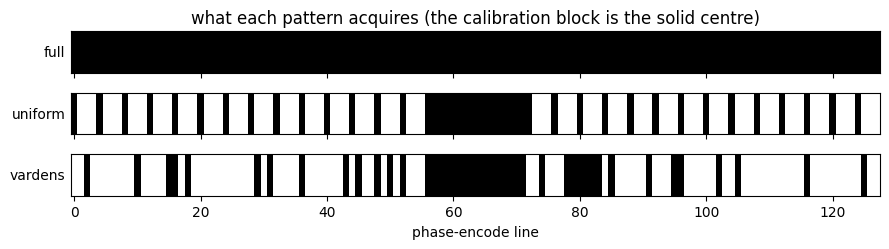

In [18]:
fig, axes = plt.subplots(len(patterns), 1, figsize=(9, 2.6), sharex=True)
for ax, (name, lines) in zip(axes, patterns.items()):
    mask = np.zeros(NY)
    mask[list(lines)] = 1.0
    ax.imshow(mask[None, :], aspect='auto', cmap='Greys', vmin=0, vmax=1,
              extent=(-0.5, NY - 0.5, 0, 1))
    ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, ha='right', va='center')
axes[-1].set_xlabel('phase-encode line')
axes[0].set_title('what each pattern acquires (the calibration block is the solid centre)')
fig.tight_layout()

## The three files

One instance of the repetition, three cheap calls. The waveforms were designed once; a different
pattern is a different loop over them, not a different sequence.

In [19]:
nominal = {}
for name, lines in patterns.items():
    tree = scan(lambda line, phase_deg=0.0, acquire=True: gre_tr(
        line=line, phase_deg=phase_deg, acquire=acquire), lines)
    seq = sc.compile(tree, opts, name=f'gre_2d_{name}', definitions={
        'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'kSpaceCenterLine': CENTER_LINE,
        'TE': gre_tr.min_te_s,
        'TR': TR_S,
        'FlipAngle': FLIP_DEG,
        'ReceiverBandwidth': BANDWIDTH_HZ_PX,
    })
    seq.write(str(SEQ_DIR / f'gre_2d_{name}.seq'))
    nominal[name] = sc.kspace(tree, opts)['k_adc'].reshape(3, len(lines), NX)
    print(f'{name:8s} {len(seq.block_events):5d} blocks   {seq.duration()[0]:6.2f} s   '
          f'-> seq/gre_2d_{name}.seq')

np.savez(
    SEQ_DIR / 'gre_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, dummies=DUMMIES, te_s=gre_tr.min_te_s, tr_s=TR_S,
    **{f'lines_{name}': np.array(lines) for name, lines in patterns.items()},
    **{f'k_{name}': k for name, k in nominal.items()},
)
print(f'-> {SEQ_DIR / "gre_2d_nominal.npz"}')

C:\Users\bughh\AppData\Local\Temp\ipykernel_77284\2625871976.py:5: SeqCraftWarning: 502 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 3.150 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (slew 165% at 3.150 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (grad 109% at 6.250 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (slew 137% at 6.250 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 13.150 ms) (+497 more sites)
  seq = sc.compile(tree, opts, name=f'gre_2d_{name}', definitions={


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 502 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 3.150 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (slew 165% at 3.150 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (grad 109% at 6.250 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (slew 137% at 6.250 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 13.150 ms) (+497 more sites)
  seq = compile_sequence(tree, opts)


full       665 blocks     1.33 s   -> seq/gre_2d_full.seq


C:\Users\bughh\AppData\Local\Temp\ipykernel_77284\2625871976.py:5: SeqCraftWarning: 170 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 3.150 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (slew 165% at 3.150 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (grad 109% at 6.250 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (slew 137% at 6.250 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 13.150 ms) (+165 more sites)
  seq = sc.compile(tree, opts, name=f'gre_2d_{name}', definitions={


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 170 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 3.150 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (slew 165% at 3.150 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (grad 109% at 6.250 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (slew 137% at 6.250 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 13.150 ms) (+165 more sites)
  seq = compile_sequence(tree, opts)


uniform    245 blocks     0.49 s   -> seq/gre_2d_uniform.seq


C:\Users\bughh\AppData\Local\Temp\ipykernel_77284\2625871976.py:5: SeqCraftWarning: 170 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 3.150 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (slew 164% at 3.150 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (grad 108% at 6.250 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (slew 135% at 6.250 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 13.150 ms) (+165 more sites)
  seq = sc.compile(tree, opts, name=f'gre_2d_{name}', definitions={


vardens    245 blocks     0.49 s   -> seq/gre_2d_vardens.seq
-> seq\gre_2d_nominal.npz


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 170 blocks over the vector-norm limit (legal on real amplifiers): scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 3.150 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (slew 164% at 3.150 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (grad 108% at 6.250 ms), scan.GRE2DTR.PhaseEncode, scan.GRE2DTR.spoiler (slew 135% at 6.250 ms), scan.GRE2DTR.CartesianLine, scan.GRE2DTR.Excitation, scan.GRE2DTR.PhaseEncode (grad 110% at 13.150 ms) (+165 more sites)
  seq = compile_sequence(tree, opts)


---
## What this notebook established

| | |
|---|---|
| the rephaser undoes the area **after the pulse's effective centre** | not half the total, which agrees only for a symmetric pulse |
| the prephaser is the **integrated moment up to the echo** | `-flat_area/2` drops the ramp; `-area/2` is half a $\Delta k$ short |
| the rephaser, the blip and the prephaser are **one winder on three axes** | waiting for the rephaser costs its whole duration in TE |
| all three are **stretched to a common duration** | a delay instead would lengthen TE for nothing |
| the receiver is **phase-locked to the transmitter** | otherwise the spoiling schedule lands in $k_y$ |
| the phase counter **runs across the dummies** | restarting it discards the steady state they just established |
| the `LIN` label is emitted by the **repetition** | a Cartesian line does not know which line it is |

Every one of those is now inside `sc.modules`, which is why pass 3 is short enough to read. The
class written above **is** `seqcraft/modules/kernel/gre_2d_tr.py`, and
`tests/modules/test_notebook_matches_the_package.py` asserts the two compile identically — so this
notebook cannot drift from the package without CI noticing.

Next: [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) takes the three
`.seq` files and asks what the sampling costs.